In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    OneHotEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:


path = "/content/drive/MyDrive/Dataset/Crop and fertilizer dataset.csv"
data = pd.read_csv(path)


In [ ]:
# data = pd.read_csv('/content/Dataset/Crop and fertilizer dataset.csv')

In [ ]:
data.isnull().sum()

,0
District_Name,0
Soil_color,0
Nitrogen,0
Phosphorus,0
Potassium,0
pH,0
Rainfall,0
Temperature,0
Crop,0
Fertilizer,0


In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4513 entries, 0 to 4512
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   District_Name  4513 non-null   object 
 1   Soil_color     4513 non-null   object 
 2   Nitrogen       4513 non-null   int64  
 3   Phosphorus     4513 non-null   int64  
 4   Potassium      4513 non-null   int64  
 5   pH             4513 non-null   float64
 6   Rainfall       4513 non-null   int64  
 7   Temperature    4513 non-null   int64  
 8   Crop           4513 non-null   object 
 9   Fertilizer     4513 non-null   object 
 10  Link           4513 non-null   object 
dtypes: float64(1), int64(5), object(5)
memory usage: 388.0+ KB


In [ ]:
data.describe()

,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature
count,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000,4513.000000
mean,95.409927,54.341901,63.595170,6.715267,819.189010,25.915134
std,38.060648,16.551991,35.691911,0.625198,251.730813,5.897328
min,20.000000,10.000000,5.000000,5.500000,300.000000,10.000000
25%,60.000000,40.000000,40.000000,6.000000,600.000000,20.000000
50%,105.000000,55.000000,55.000000,6.500000,800.000000,25.000000
75%,125.000000,65.000000,75.000000,7.000000,1000.000000,30.000000
max,150.000000,90.000000,150.000000,8.500000,1700.000000,40.000000


<Axes: >

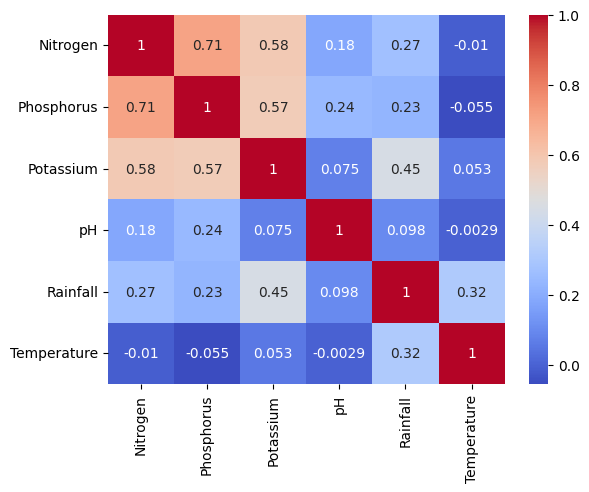

In [ ]:
sns.heatmap((data.drop(columns=['Crop', 'Fertilizer', 'District_Name', 'Soil_color', 'Link'])).corr(), annot=True,cbar=True , cmap='coolwarm')

In [ ]:
data.head()

,District_Name,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer,Link
0,Kolhapur,Black,75,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
1,Kolhapur,Black,80,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
2,Kolhapur,Black,85,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
3,Kolhapur,Black,90,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo
4,Kolhapur,Black,95,50,100,6.5,1000,20,Sugarcane,Urea,https://youtu.be/2t5Am0xLTOo


In [ ]:
data.drop(columns=['District_Name', 'Link'], inplace=True)
data.head()

,Soil_color,Nitrogen,Phosphorus,Potassium,pH,Rainfall,Temperature,Crop,Fertilizer
0,Black,75,50,100,6.5,1000,20,Sugarcane,Urea
1,Black,80,50,100,6.5,1000,20,Sugarcane,Urea
2,Black,85,50,100,6.5,1000,20,Sugarcane,Urea
3,Black,90,50,100,6.5,1000,20,Sugarcane,Urea
4,Black,95,50,100,6.5,1000,20,Sugarcane,Urea


In [ ]:
crops = data['Crop'].unique()

In [ ]:
fertz = data['Fertilizer'].unique()
fertz

array(['Urea', 'DAP', 'MOP', '10:26:26 NPK', 'SSP', 'Magnesium Sulphate',
       '13:32:26 NPK', '12:32:16 NPK', '50:26:26 NPK', '19:19:19 NPK',
       'Chilated Micronutrient', '18:46:00 NPK', 'Sulphur',
       '20:20:20 NPK', 'Ammonium Sulphate', 'Ferrous Sulphate',
       'White Potash', '10:10:10 NPK', 'Hydrated Lime'], dtype=object)

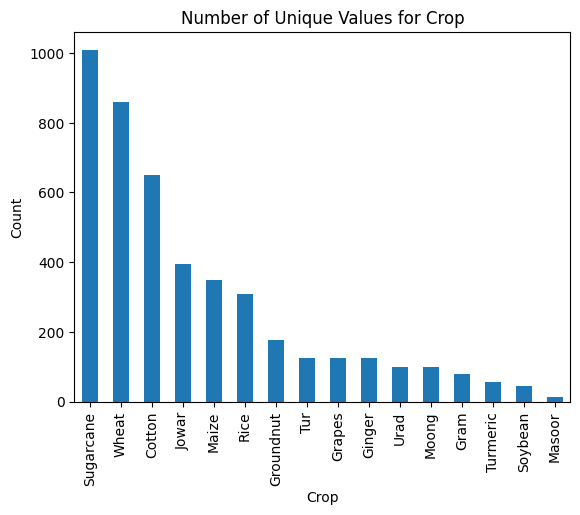

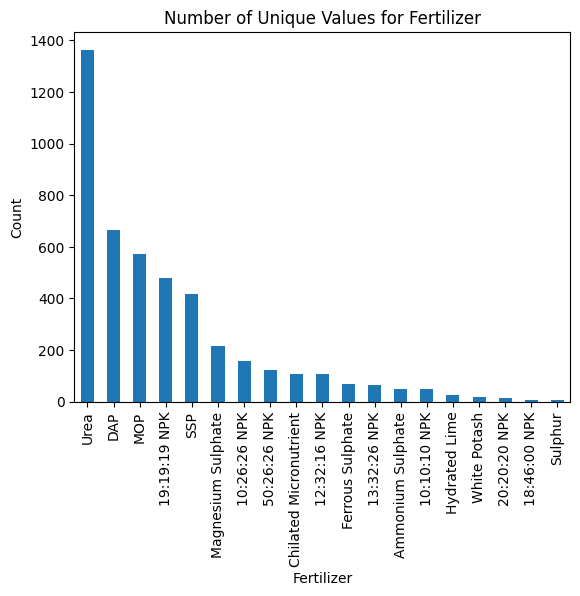

In [ ]:
import matplotlib.pyplot as plt

# Count unique values
crop_counts = data["Crop"].value_counts()
fertilizer_counts = data["Fertilizer"].value_counts()

# Crop graph
plt.figure()
crop_counts.plot(kind='bar')
plt.title("Number of Unique Values for Crop")
plt.xlabel("Crop")
plt.ylabel("Count")
plt.show()

# Fertilizer graph
plt.figure()
fertilizer_counts.plot(kind='bar')
plt.title("Number of Unique Values for Fertilizer")
plt.xlabel("Fertilizer")
plt.ylabel("Count")
plt.show()


In [ ]:
invalid_ranges = {
    "Nitrogen": (0, 200),
    "Phosphorus": (0, 150),
    "Potassium": (0, 300),
    "pH": (0, 14),
    "Rainfall": (0, None),        # no upper hard limit
    "Temperature": (-20, 60)
}

print("Unrealistic values check\n")

for col, (low, high) in invalid_ranges.items():
    if high is not None:
        invalid = data[(data[col] < low) | (data[col] > high)]
    else:
        invalid = data[data[col] < low]

    print(f"{col}: {invalid.shape[0]} invalid values")


Unrealistic values check

Nitrogen: 0 invalid values
Phosphorus: 0 invalid values
Potassium: 0 invalid values
pH: 0 invalid values
Rainfall: 0 invalid values
Temperature: 0 invalid values


In [ ]:
len(data["Soil_color"].unique())

7

In [ ]:

num_cols = [
    "Nitrogen", "Phosphorus", "Potassium",
    "pH", "Rainfall", "Temperature"
]

cat_cols = ["Soil_color"]



In [ ]:
X_crop = data[num_cols + cat_cols]
y_crop = data["Crop"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_crop, y_crop,
    test_size=0.2,
    stratify=y_crop,
    random_state=42
)

le_crop = LabelEncoder()
yc_train_enc = le_crop.fit_transform(yc_train)
yc_test_enc = le_crop.transform(yc_test)

crop_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

crop_model = Pipeline([
    ("preprocess", crop_preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ))
])

crop_model.fit(Xc_train, yc_train_enc)

crop_preds = crop_model.predict(Xc_test)

print("Crop Recommendation Report\n")
print(classification_report(
    yc_test_enc,
    crop_preds,
    target_names=le_crop.classes_
))

joblib.dump(crop_model, "crop_model.pkl")
joblib.dump(le_crop, "crop_label_encoder.pkl")


Crop Recommendation Report

              precision    recall  f1-score   support

      Cotton       1.00      1.00      1.00       130
      Ginger       1.00      1.00      1.00        25
        Gram       1.00      1.00      1.00        16
      Grapes       1.00      1.00      1.00        25
   Groundnut       1.00      1.00      1.00        35
       Jowar       0.98      1.00      0.99        79
       Maize       0.97      1.00      0.99        70
      Masoor       1.00      1.00      1.00         2
       Moong       1.00      1.00      1.00        20
        Rice       1.00      1.00      1.00        62
     Soybean       1.00      1.00      1.00         9
   Sugarcane       1.00      1.00      1.00       202
         Tur       1.00      1.00      1.00        25
    Turmeric       1.00      0.82      0.90        11
        Urad       1.00      1.00      1.00        20
       Wheat       1.00      0.99      0.99       172

    accuracy                           1.00       90

['crop_label_encoder.pkl']

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
fert_cat_cols = cat_cols + ["Crop"]

X_fert = data[num_cols + fert_cat_cols]
y_fert = data["Fertilizer"]

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fert, y_fert,
    test_size=0.2,
    stratify=y_fert,
    random_state=42
)

le_fert = LabelEncoder()
yf_train_enc = le_fert.fit_transform(yf_train)
yf_test_enc = le_fert.transform(yf_test)

fert_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), fert_cat_cols)
])


fert_model = Pipeline([
    ("preprocess", fert_preprocessor),
    ( "clf",XGBClassifier(
        objective="multi:softmax",
        eval_metric="mlogloss",
        random_state=42
    ))
])


fert_model.fit(
    Xf_train,
    yf_train_enc
)

fert_preds = fert_model.predict(Xf_test)

print("Fertilizer Recommendation Report\n")
print(classification_report(
    yf_test_enc,
    fert_preds,
    target_names=le_fert.classes_
))

joblib.dump(fert_model, "fertilizer_model.pkl")
joblib.dump(le_fert, "fertilizer_label_encoder.pkl")



Fertilizer Recommendation Report

                        precision    recall  f1-score   support

          10:10:10 NPK       1.00      1.00      1.00        10
          10:26:26 NPK       1.00      1.00      1.00        31
          12:32:16 NPK       1.00      1.00      1.00        21
          13:32:26 NPK       1.00      1.00      1.00        13
          18:46:00 NPK       1.00      1.00      1.00         1
          19:19:19 NPK       0.99      0.98      0.98        96
          20:20:20 NPK       1.00      1.00      1.00         3
          50:26:26 NPK       0.96      0.92      0.94        25
     Ammonium Sulphate       1.00      1.00      1.00        10
Chilated Micronutrient       0.81      1.00      0.90        22
                   DAP       0.95      0.99      0.97       134
      Ferrous Sulphate       1.00      1.00      1.00        14
         Hydrated Lime       1.00      1.00      1.00         5
                   MOP       0.97      0.90      0.94       114
    M

['fertilizer_label_encoder.pkl']

In [ ]:

fert_cat_cols = cat_cols + ["Crop"]

X_fert = data[num_cols + fert_cat_cols]
y_fert = data["Fertilizer"]

Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fert,
    y_fert,
    test_size=0.2,
    stratify=y_fert,
    random_state=42
)

le_fert = LabelEncoder()
yf_train_enc = le_fert.fit_transform(yf_train)
yf_test_enc = le_fert.transform(yf_test)


fert_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), fert_cat_cols)
])

fert_model = Pipeline([
    ("preprocess", fert_preprocessor),
    ("clf", XGBClassifier(
        objective="multi:softprob",
        num_class=len(le_fert.classes_),
        n_estimators=1500,
        max_depth=13,
        learning_rate=0.1,
        eval_metric="mlogloss",
        random_state=42
    ))
])


sample_weights = compute_sample_weight(
    class_weight="balanced",
    y=yf_train_enc
)

fert_model.fit(
    Xf_train,
    yf_train_enc,
    clf__sample_weight=sample_weights
)

fert_preds = fert_model.predict(Xf_test)

print("\nFertilizer Recommendation Report\n")
print(classification_report(
    yf_test_enc,
    fert_preds,
    target_names=le_fert.classes_
))

joblib.dump(fert_model, "fertilizer_model_Xg.pkl")
joblib.dump(le_fert, "fertilizer_label_encoder.pkl")



Fertilizer Recommendation Report

                        precision    recall  f1-score   support

          10:10:10 NPK       1.00      1.00      1.00        10
          10:26:26 NPK       0.97      1.00      0.98        31
          12:32:16 NPK       0.91      1.00      0.95        21
          13:32:26 NPK       1.00      1.00      1.00        13
          18:46:00 NPK       1.00      1.00      1.00         1
          19:19:19 NPK       0.99      0.98      0.98        96
          20:20:20 NPK       1.00      1.00      1.00         3
          50:26:26 NPK       0.93      1.00      0.96        25
     Ammonium Sulphate       1.00      1.00      1.00        10
Chilated Micronutrient       0.85      1.00      0.92        22
                   DAP       0.97      0.99      0.98       134
      Ferrous Sulphate       0.88      1.00      0.93        14
         Hydrated Lime       1.00      1.00      1.00         5
                   MOP       0.98      0.96      0.97       114
    

['fertilizer_label_encoder.pkl']